# 1: Organizando

### 1.1: Importando as bibliotecas

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, average_precision_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline



### 1.2: Carregando os dados

In [116]:
df = pd.read_csv("dados_usados/dados_para_modelo.csv")

In [117]:
df.head(10)

,status_do_emprestimo,valor_do_emprestimo,prazo_do_emprestimo_meses,taxa_de_juros,valor_da_parcela,tempo_de_emprego_anos,renda_anual,data_de_emissao_do_emprestimo,relacao_divida_renda,primeira_linha_de_credito,...,total_de_contas_de_credito,contas_de_hipoteca,registros_de_falencia,classificacao_de_risco,tipo_de_moradia,finalidade_do_emprestimo,tipo_de_aplicacao,taxa_de_juros_agrupada,taxa/falencia,juros/contas
0,0,10000.0,36,11.44,329.48,10.0,117000.0,2015,26.24,1990,...,25.0,0.0,0.0,0.874270,0.773378,0.810767,0.803913,0.25,11.44,64.0
1,0,8000.0,36,11.99,265.68,4.0,65000.0,2015,22.05,2004,...,27.0,3.0,0.0,0.874270,0.830439,0.792586,0.803913,0.50,11.99,34.0
2,0,15600.0,36,10.49,506.97,0.0,43057.0,2015,12.79,2007,...,26.0,0.0,0.0,0.874270,0.773378,0.832882,0.803913,0.25,10.49,52.0
3,0,7200.0,36,6.49,220.65,6.0,54000.0,2014,2.60,2006,...,13.0,0.0,0.0,0.937121,0.773378,0.832882,0.803913,0.25,6.49,24.0
4,1,24375.0,60,17.27,609.33,9.0,55000.0,2013,33.95,1999,...,43.0,1.0,0.0,0.788191,0.830439,0.832882,0.803913,0.50,17.27,26.0
5,0,20000.0,36,13.33,677.07,10.0,86788.0,2015,16.31,2005,...,23.0,4.0,0.0,0.788191,0.830439,0.792586,0.803913,0.50,13.33,16.0
6,0,18000.0,36,5.32,542.07,2.0,125000.0,2015,1.36,2005,...,25.0,3.0,0.0,0.937121,0.830439,0.829921,0.803913,0.25,5.32,32.0
7,0,13000.0,36,11.14,426.47,10.0,46000.0,2012,26.87,1994,...,15.0,0.0,0.0,0.874270,0.773378,0.832882,0.803913,0.25,11.14,44.0
8,0,18900.0,60,10.99,410.84,10.0,103000.0,2014,12.52,1994,...,40.0,3.0,0.0,0.874270,0.773378,0.792586,0.803913,0.25,10.99,52.0
9,0,26300.0,36,16.29,928.40,3.0,115000.0,2012,23.69,1997,...,37.0,1.0,0.0,0.788191,0.830439,0.792586,0.803913,0.50,16.29,26.0


In [127]:
df.tail(10)

,status_do_emprestimo,valor_do_emprestimo,prazo_do_emprestimo_meses,taxa_de_juros,valor_da_parcela,tempo_de_emprego_anos,renda_anual,data_de_emissao_do_emprestimo,relacao_divida_renda,primeira_linha_de_credito,...,total_de_contas_de_credito,contas_de_hipoteca,registros_de_falencia,classificacao_de_risco,tipo_de_moradia,finalidade_do_emprestimo,tipo_de_aplicacao,taxa_de_juros_agrupada,taxa/falencia,juros/contas
383411,0,10000.0,36,9.76,321.55,10.0,40000.0,2015,23.40,1988,...,18.0,1.0,0.0,0.874270,0.773378,0.792586,0.803913,0.25,9.76,36.0
383412,0,3200.0,36,5.42,96.52,10.0,33000.0,2011,21.45,1996,...,50.0,1.0,0.0,0.937121,0.773378,0.792586,0.803913,0.25,5.42,72.0
383413,0,12000.0,36,12.29,400.24,1.0,52100.0,2015,17.28,2004,...,18.0,0.0,0.0,0.788191,0.773378,0.792586,0.803913,0.50,12.29,12.0
383414,0,22000.0,36,18.92,805.55,10.0,138000.0,2014,24.43,1998,...,39.0,4.0,0.0,0.711322,0.830439,0.792586,0.803913,0.75,18.92,24.0
383415,0,6000.0,36,13.11,202.49,5.0,64000.0,2013,10.81,1991,...,9.0,0.0,0.0,0.874270,0.773378,0.792586,0.803913,0.50,13.11,14.0
383416,0,10000.0,60,10.99,217.38,2.0,40000.0,2015,15.63,2004,...,23.0,0.0,0.0,0.874270,0.773378,0.792586,0.803913,0.25,10.99,24.0
383417,0,21000.0,36,12.29,700.42,5.0,110000.0,2015,21.45,2006,...,8.0,1.0,0.0,0.788191,0.830439,0.792586,0.803913,0.50,12.29,12.0
383418,0,5000.0,36,9.99,161.32,10.0,56500.0,2013,17.56,1997,...,23.0,0.0,0.0,0.874270,0.773378,0.792586,0.803913,0.25,9.99,60.0
383419,0,21000.0,60,15.31,503.02,10.0,64000.0,2012,15.88,1990,...,20.0,5.0,0.0,0.788191,0.830439,0.792586,0.803913,0.50,15.31,18.0
383420,0,2000.0,36,13.61,67.98,10.0,42996.0,2010,8.32,1998,...,19.0,1.0,0.0,0.788191,0.773378,0.792586,0.803913,0.50,13.61,6.0


### 1.3: Separando dados de treino e teste

In [ ]:
# x = todos os dados do df, menos a coluna "status_do_emprestimo" que o modelo tentara prever
# y = a coluna "status_do_emprestimo" que o modelo tentara prever

x = df.drop("status_do_emprestimo", axis=1)
y = df["status_do_emprestimo"]

In [119]:
x.info()

<class 'pandas.DataFrame'>
RangeIndex: 383421 entries, 0 to 383420
Data columns (total 23 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   valor_do_emprestimo             383421 non-null  float64
 1   prazo_do_emprestimo_meses       383421 non-null  int64  
 2   taxa_de_juros                   383421 non-null  float64
 3   valor_da_parcela                383421 non-null  float64
 4   tempo_de_emprego_anos           383421 non-null  float64
 5   renda_anual                     383421 non-null  float64
 6   data_de_emissao_do_emprestimo   383421 non-null  int64  
 7   relacao_divida_renda            383421 non-null  float64
 8   primeira_linha_de_credito       383421 non-null  int64  
 9   contas_de_credito_abertas       383421 non-null  float64
 10  registros_publicos_negativos    383421 non-null  float64
 11  saldo_de_credito_rotativo       383421 non-null  float64
 12  utilizacao_do_credito_rotat

In [120]:
y.value_counts()

status_do_emprestimo
0    308372
1     75049
Name: count, dtype: int64

In [121]:
x_train, x_test, y_train, y_test= train_test_split(x, y, test_size=0.2, stratify= y, random_state=42)

In [122]:
len(x_train), len(y_train)

(306736, 306736)

In [123]:
len(x_test), len(y_test)

(76685, 76685)

In [124]:
pipeline_logistic = Pipeline(
   [ ("scaler", StandardScaler()),
    ("model", LogisticRegression())]
)

pipeline_knn = Pipeline(
    [("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())]
)

In [125]:
modelos = {
    "KNN" : pipeline_knn,
    "Logistic Regressionr" : pipeline_logistic,
    "Ramdom Forest" : RandomForestClassifier(random_state=42),
    "XGBoosting" : XGBClassifier(random_state=42),
    "Lightgbm" : LGBMClassifier(random_state=42)
}

In [126]:
avaliacao = {}

for name, modelo in modelos.items():
    cross_score = cross_val_score(
        modelo, x_train, y_train,
        cv=5,
        scoring= "roc_auc"
    )
    avaliacao[name] = np.mean(cross_score)
    print(f"{name} : {avaliacao[name]}")


KNN : 0.6263537498328859
Logistic Regressionr : 0.707326491157081


KeyboardInterrupt: 

In [ ]:
knn_params = {
  "model__n_neighbors" : [1, 3, 5, 7, 9, 20, 30, 50],
  "model__weights" : ["uniform", "distance"]
}

random_forest_params = {
    "n_estimators" : np.arange(300, 1500, 90),
    "max_depth" : [1, 5, 9, 20, 50],
    "min_samples_leaf" : np.arange(1, 10, 3),
    "min_samples_split" : np.arange(1, 15, 3)
}

logistic_params = {
    "model__C" : np.logspace(-3, 3, 10),
    "model__solver" : ["lbfgs", "liblinear"]
}

gradient_boosting_params = {
    "n_estimators" : np.arange(100, 1080, 80),
    "max_depth" : [1, 3, 9, 15],
    "subsample" : [0.2, 0.5, 0.7, 1],
    "min_child_weight" : np.arange(1, 10, 3),
    "scale_pos_weight" : [10, 20, 5, 15, ]
}

light_params = {
    "num_leaves" : [63, 127],
    "n_estimators" : [100, 300, 500, 1000],
    "min_child_sample" : [100, 300, 500, 1000],
    "max_depth" : [1, 5, 7],
    "subsample" : [0.2, 0.5, 1],
    "is_unbalance" : [True],
    "colsample_bytree" : [0.2, 1],
    "learning_rate" : [0.2, 1],
    "force_row_wise" : [True]
}



In [ ]:
x_sample,_, y_sample,_ = train_test_split(x_train, y_train, train_size=100000, stratify=y_train, random_state=42)

In [ ]:
def test_randomized_search(model, params, x_sample, y_sample):
    randomized = HalvingRandomSearchCV(
    model,
    params,
    cv= 5,
    n_candidates = 50,
    factor=3,
    scoring="f1",
    n_jobs = -1,
    min_resources= 6000,
    random_state=42,
    verbose=2
)

    randomized.fit(x_sample, y_sample)
    print(f"O melhor score foi: {randomized.best_score_}")
    print(f"Os melhores parametros foram: {randomized.best_params_}")

    return randomized
    


In [ ]:
knn_modelo = test_randomized_search(pipeline_knn, knn_params, x_train, y_train)

n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 4
min_resources_: 6000
max_resources_: 306736
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 16
n_resources: 6000
Fitting 5 folds for each of 16 candidates, totalling 80 fits


/home/Erick/miniconda3/envs/data/lib/python3.11/site-packages/sklearn/model_selection/_search.py:324: UserWarning: The total space of parameters 16 is smaller than n_iter=50. Running 16 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


[CV] END ......model__n_neighbors=1, model__weights=distance; total time=   0.1s
[CV] END .......model__n_neighbors=1, model__weights=uniform; total time=   0.2s
[CV] END .......model__n_neighbors=1, model__weights=uniform; total time=   0.1s
[CV] END .......model__n_neighbors=1, model__weights=uniform; total time=   0.1s
[CV] END ......model__n_neighbors=1, model__weights=distance; total time=   0.1s
[CV] END .......model__n_neighbors=1, model__weights=uniform; total time=   0.2s
[CV] END .......model__n_neighbors=1, model__weights=uniform; total time=   0.1s
[CV] END ......model__n_neighbors=1, model__weights=distance; total time=   0.1s
[CV] END ......model__n_neighbors=1, model__weights=distance; total time=   0.1s
[CV] END ......model__n_neighbors=1, model__weights=distance; total time=   0.1s
[CV] END .......model__n_neighbors=3, model__weights=uniform; total time=   0.1s
[CV] END .......model__n_neighbors=3, model__weights=uniform; total time=   0.1s
[CV] END .......model__n_nei

In [ ]:
logistic_modelo = test_randomized_search(pipeline_logistic, logistic_params, x_train, y_train)

n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 4
min_resources_: 6000
max_resources_: 306736
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 20
n_resources: 6000
Fitting 5 folds for each of 20 candidates, totalling 100 fits


/home/Erick/miniconda3/envs/data/lib/python3.11/site-packages/sklearn/model_selection/_search.py:324: UserWarning: The total space of parameters 20 is smaller than n_iter=50. Running 20 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


[CV] END ................model__C=0.001, model__solver=lbfgs; total time=   0.1s
[CV] END ................model__C=0.001, model__solver=lbfgs; total time=   0.1s
[CV] END ................model__C=0.001, model__solver=lbfgs; total time=   0.1s
[CV] END ................model__C=0.001, model__solver=lbfgs; total time=   0.1s
[CV] END ............model__C=0.001, model__solver=liblinear; total time=   0.1s
[CV] END ................model__C=0.001, model__solver=lbfgs; total time=   0.1s
[CV] END ............model__C=0.001, model__solver=liblinear; total time=   0.2s
[CV] END ............model__C=0.001, model__solver=liblinear; total time=   0.2s
[CV] END .model__C=0.004641588833612777, model__solver=lbfgs; total time=   0.1s
[CV] END ............model__C=0.001, model__solver=liblinear; total time=   0.1s
[CV] END .model__C=0.004641588833612777, model__solver=lbfgs; total time=   0.1s
[CV] END .model__C=0.004641588833612777, model__solver=lbfgs; total time=   0.1s
[CV] END ............model__

In [ ]:
xgb_modelo = test_randomized_search(XGBClassifier(), gradient_boosting_params, x_train, y_train)

n_iterations: 4
n_required_iterations: 4
n_possible_iterations: 4
min_resources_: 6000
max_resources_: 306736
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 50
n_resources: 6000
Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END max_depth=15, min_child_weight=7, n_estimators=100, scale_pos_weight=10, subsample=1; total time=   2.5s
[CV] END max_depth=15, min_child_weight=7, n_estimators=100, scale_pos_weight=10, subsample=1; total time=   2.5s
[CV] END max_depth=15, min_child_weight=7, n_estimators=100, scale_pos_weight=10, subsample=1; total time=   2.6s
[CV] END max_depth=15, min_child_weight=7, n_estimators=100, scale_pos_weight=10, subsample=1; total time=   2.6s
[CV] END max_depth=15, min_child_weight=7, n_estimators=100, scale_pos_weight=10, subsample=1; total time=   2.6s
[CV] END max_depth=3, min_child_weight=4, n_estimators=420, scale_pos_weight=20, subsample=0.7; total time=   0.6s
[CV] END max_depth=3, min_child_weight=4, n_estim

In [ ]:
#lightgbm testando os hiperparametros estava travando meu pc, então não pude testar, 
# mas mesmo testando hiperparametros dos outros modelos, 
# ele ainda é um pouco superior mesmo sem ajustar os hiperparametros
#light_modelo = test_randomized_search(LGBMClassifier(), light_params, x_sample, y_sample)

In [ ]:
#coloquei so um sample de 100.000 linhas para testar os hiperparametros do random forest, para rodar mais rapido e pesar menos no pc
random_forest_modelo = test_randomized_search(RandomForestClassifier(), random_forest_params, x_sample, y_sample)

n_iterations: 3
n_required_iterations: 4
n_possible_iterations: 3
min_resources_: 6000
max_resources_: 100000
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 50
n_resources: 6000
Fitting 5 folds for each of 50 candidates, totalling 250 fits


[CV] END max_depth=5, min_samples_leaf=7, min_samples_split=1, n_estimators=480; total time=   0.0s
[CV] END max_depth=5, min_samples_leaf=7, min_samples_split=1, n_estimators=480; total time=   0.0s
[CV] END max_depth=5, min_samples_leaf=7, min_samples_split=1, n_estimators=480; total time=   0.0s
[CV] END max_depth=5, min_samples_leaf=7, min_samples_split=1, n_estimators=480; total time=   0.0s
[CV] END max_depth=5, min_samples_leaf=7, min_samples_split=1, n_estimators=480; total time=   0.0s
[CV] END max_depth=20, min_samples_leaf=1, min_samples_split=13, n_estimators=570; total time=   7.2s
[CV] END max_depth=20, min_samples_leaf=1, min_samples_split=13, n_estimators=570; total time=   7.3s
[CV] END max_depth=20, min_samples_leaf=1, min_samples_split=13, n_estimators=570; total time=   8.0s
[CV] END max_depth=20, min_samples_leaf=1, min_samples_split=13, n_estimators=570; total time=   8.4s
[CV] END max_depth=20, min_samples_leaf=1, min_samples_split=13, n_estimators=570; total tim

/home/Erick/miniconda3/envs/data/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
65 fits failed out of a total of 250.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
65 fits failed with the following error:
Traceback (most recent call last):
  File "/home/Erick/miniconda3/envs/data/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/Erick/miniconda3/envs/data/lib/python3.11/site-packages/sklearn/base.py", line 1329, in wrapper
    estimator._validate_params()
  File "/home/Erick/miniconda3/envs/data/lib/python3.11/site-packages/sklearn/base.py", line 492, in _validate_params
    valida

[CV] END max_depth=50, min_samples_leaf=7, min_samples_split=10, n_estimators=480; total time=  14.5s
[CV] END max_depth=20, min_samples_leaf=7, min_samples_split=13, n_estimators=480; total time=  14.6s
[CV] END max_depth=20, min_samples_leaf=7, min_samples_split=13, n_estimators=480; total time=  14.6s
[CV] END max_depth=50, min_samples_leaf=7, min_samples_split=10, n_estimators=480; total time=  14.9s
[CV] END max_depth=50, min_samples_leaf=7, min_samples_split=10, n_estimators=480; total time=  15.1s
[CV] END max_depth=50, min_samples_leaf=7, min_samples_split=10, n_estimators=480; total time=  15.2s
[CV] END max_depth=50, min_samples_leaf=7, min_samples_split=10, n_estimators=480; total time=  15.6s
[CV] END max_depth=20, min_samples_leaf=7, min_samples_split=13, n_estimators=480; total time=  15.4s
[CV] END max_depth=20, min_samples_leaf=7, min_samples_split=13, n_estimators=480; total time=  19.7s
[CV] END max_depth=20, min_samples_leaf=7, min_samples_split=13, n_estimators=480;

/home/Erick/miniconda3/envs/data/lib/python3.11/site-packages/sklearn/model_selection/_search.py:1137: UserWarning: One or more of the test scores are non-finite: [       nan 0.69916953 0.70991013 0.71110492 0.69378243 0.70985609
 0.69409841        nan 0.69414349 0.70404559 0.70980351 0.69830386
 0.69384165 0.70952648        nan 0.70599969 0.71027416 0.71063908
 0.69793283 0.69557289 0.71072836        nan        nan 0.70620241
        nan 0.69369345        nan        nan 0.71057289 0.69373018
        nan 0.71042945        nan 0.70444118 0.6944     0.70390209
 0.70978704 0.7106415         nan 0.71051518 0.70448829 0.70241073
 0.69887581 0.69652071        nan 0.69396905 0.69400169 0.70974552
 0.70652562        nan 0.71453398 0.71438792 0.71497801 0.71584957
 0.71542765 0.71644012 0.71611632 0.71561615 0.71600742 0.71645249
 0.71158105 0.71141271 0.71152967 0.71583641 0.71145091 0.71098476
 0.71173031]
  warnings.warn(
/home/Erick/miniconda3/envs/data/lib/python3.11/site-packages/sklearn/

[CV] END max_depth=9, min_samples_leaf=1, min_samples_split=13, n_estimators=930; total time= 1.3min
[CV] END max_depth=9, min_samples_leaf=1, min_samples_split=13, n_estimators=930; total time= 1.3min
[CV] END max_depth=9, min_samples_leaf=1, min_samples_split=13, n_estimators=930; total time= 1.4min
[CV] END max_depth=9, min_samples_leaf=1, min_samples_split=13, n_estimators=930; total time= 1.4min
[CV] END max_depth=9, min_samples_leaf=1, min_samples_split=13, n_estimators=930; total time= 1.4min
[CV] END max_depth=9, min_samples_leaf=1, min_samples_split=10, n_estimators=1470; total time= 2.1min
[CV] END max_depth=9, min_samples_leaf=1, min_samples_split=10, n_estimators=1470; total time= 2.1min
[CV] END max_depth=9, min_samples_leaf=1, min_samples_split=10, n_estimators=1470; total time= 2.2min
[CV] END max_depth=9, min_samples_leaf=1, min_samples_split=13, n_estimators=1110; total time= 1.6min
[CV] END max_depth=9, min_samples_leaf=1, min_samples_split=13, n_estimators=1110; tota

/home/Erick/miniconda3/envs/data/lib/python3.11/site-packages/sklearn/model_selection/_search.py:1137: UserWarning: One or more of the test scores are non-finite: [       nan 0.69916953 0.70991013 0.71110492 0.69378243 0.70985609
 0.69409841        nan 0.69414349 0.70404559 0.70980351 0.69830386
 0.69384165 0.70952648        nan 0.70599969 0.71027416 0.71063908
 0.69793283 0.69557289 0.71072836        nan        nan 0.70620241
        nan 0.69369345        nan        nan 0.71057289 0.69373018
        nan 0.71042945        nan 0.70444118 0.6944     0.70390209
 0.70978704 0.7106415         nan 0.71051518 0.70448829 0.70241073
 0.69887581 0.69652071        nan 0.69396905 0.69400169 0.70974552
 0.70652562        nan 0.71453398 0.71438792 0.71497801 0.71584957
 0.71542765 0.71644012 0.71611632 0.71561615 0.71600742 0.71645249
 0.71158105 0.71141271 0.71152967 0.71583641 0.71145091 0.71098476
 0.71173031 0.71547189 0.71550486 0.71559208 0.71557115 0.71570746
 0.71568009]
  warnings.warn(
/ho

O melhor score foi: 0.7157074582351497
Os melhores parametros foram: {'n_estimators': np.int64(750), 'min_samples_split': np.int64(13), 'min_samples_leaf': np.int64(4), 'max_depth': 9}


In [ ]:
best_modelo = XGBClassifier(subsample = 1, scale_pos_weight = 5, n_estimators = np.int64(260), min_child_weight = np.int64(7), max_depth = 3)

In [ ]:
best_modelo.fit(x_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [ ]:
y_proba = best_modelo.predict_proba(x_test)[0:, 1]

In [ ]:
y_proba

array([0.7457275 , 0.77247393, 0.54420245, ..., 0.08396982, 0.63574684,
       0.23041436], shape=(76685,), dtype=float32)

In [ ]:
roc_auc = roc_auc_score(y_test, y_proba)
roc_auc

0.7305471904016427

In [ ]:
#fui testando perto do valor do threshold de 0.70, o melhor foi esse
y_pred = (y_proba >= 0.7).astype(int)

In [ ]:
f1 = f1_score(y_test, y_pred)
f1

0.405895532838538

In [ ]:
precision = precision_score(y_test, y_pred)
precision

0.4055632488409898

In [ ]:
recall = recall_score(y_test, y_pred)
recall

0.4487674883411059

In [ ]:
average = average_precision_score(y_test, y_proba)
average

0.395626592469624

In [ ]:
matriz_confusao = confusion_matrix(y_test, y_pred)

In [ ]:
matriz_confusao

array([[51802,  9873],
       [ 8274,  6736]])

In [ ]:
probabilidade_acertos_bons_pagadores = (1 / ((matriz_confusao[1][0] + matriz_confusao[0][0]) / matriz_confusao[0][0])) * 100
probabilidade_acertos_inadimplestes = (1 / ((matriz_confusao[1][1] + matriz_confusao[0][1] ) / matriz_confusao[1][1])) * 100

In [ ]:
print(f"a probabilidade de acertar bons pagadores com esse threshold é {probabilidade_acertos_bons_pagadores}")
print(f"a probabilidade de acertar inadimplentes com esse threshold é {probabilidade_acertos_inadimplestes}")


a probabilidade de acertar bons pagadores com esse threshold é 85.40653561641666
a probabilidade de acertar inadimplentes com esse threshold é 42.769662092371256


In [ ]:
shap.initjs()

In [ ]:
explaned = shap.TreeExplainer(best_modelo)
shap_values = explaned(x_test)

In [ ]:
shap_values.shape


(76685, 23)

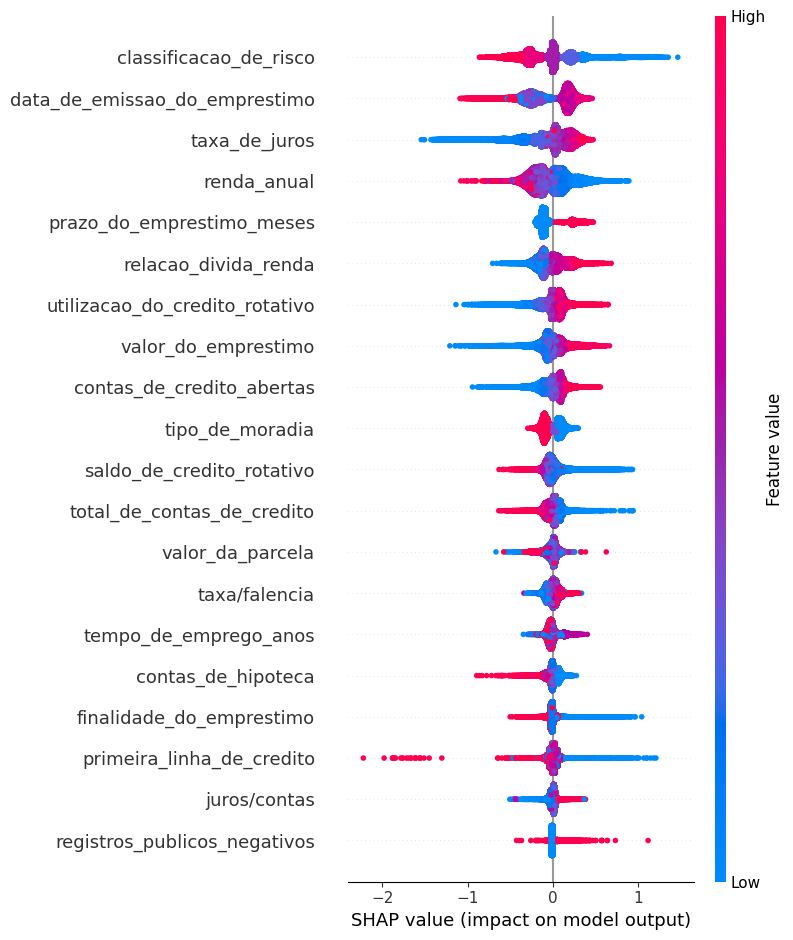

In [ ]:
sumario1 = shap.summary_plot(shap_values, x_test)

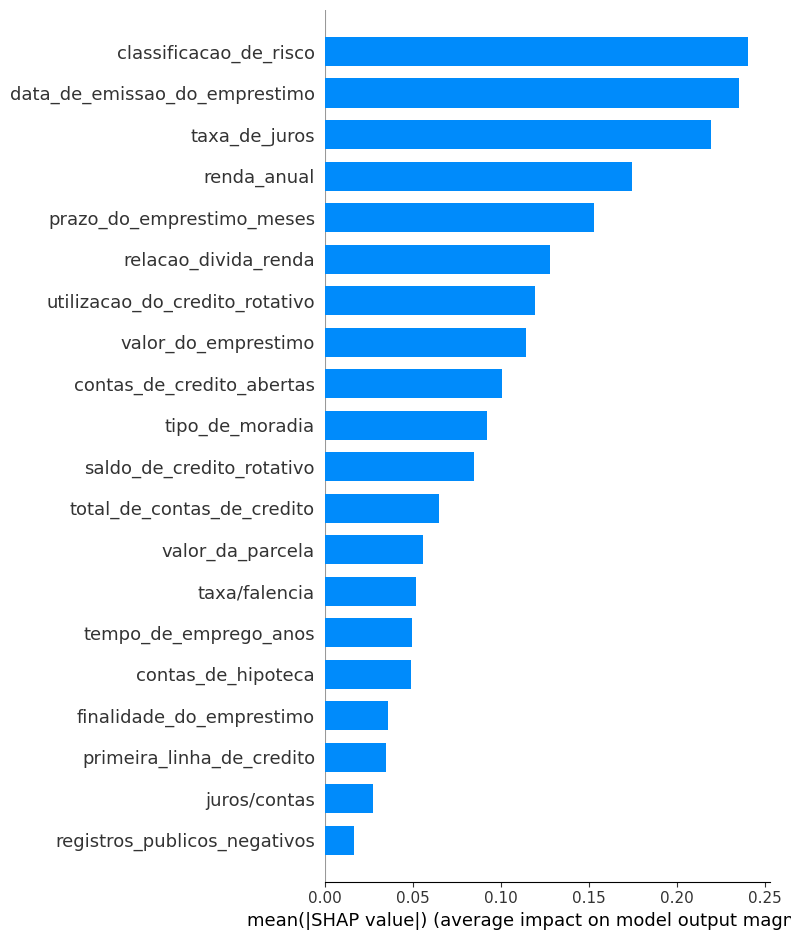

In [ ]:
sumario2 = shap.summary_plot(shap_values, x_train, plot_type="bar")

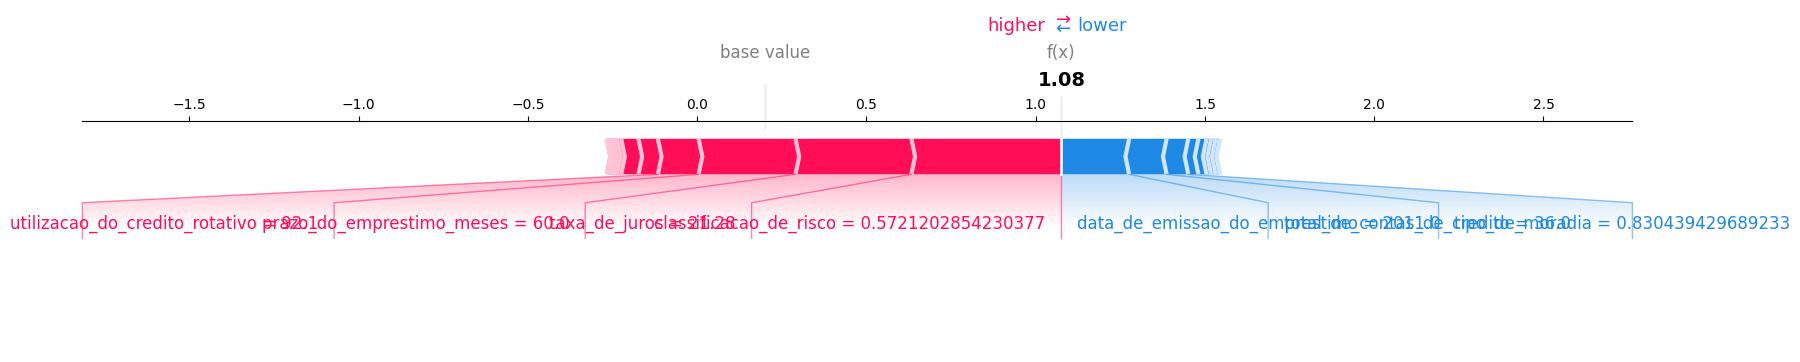

In [ ]:
grafico_forca = shap.force_plot(shap_values[0], matplotlib=True)

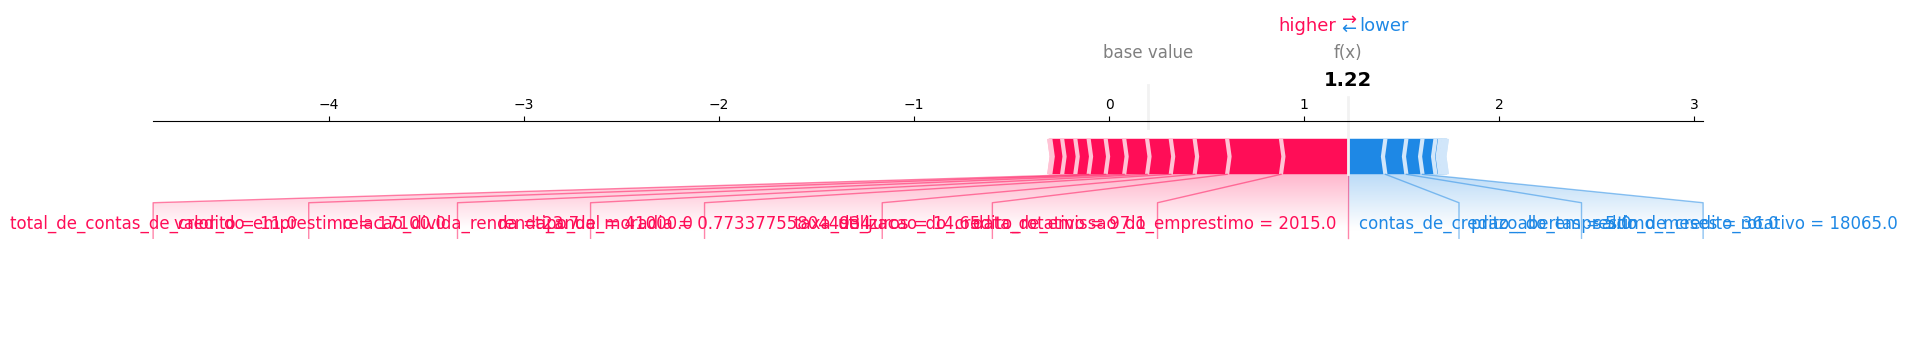

In [ ]:
grafico_forca = shap.force_plot(shap_values[1], matplotlib=True)

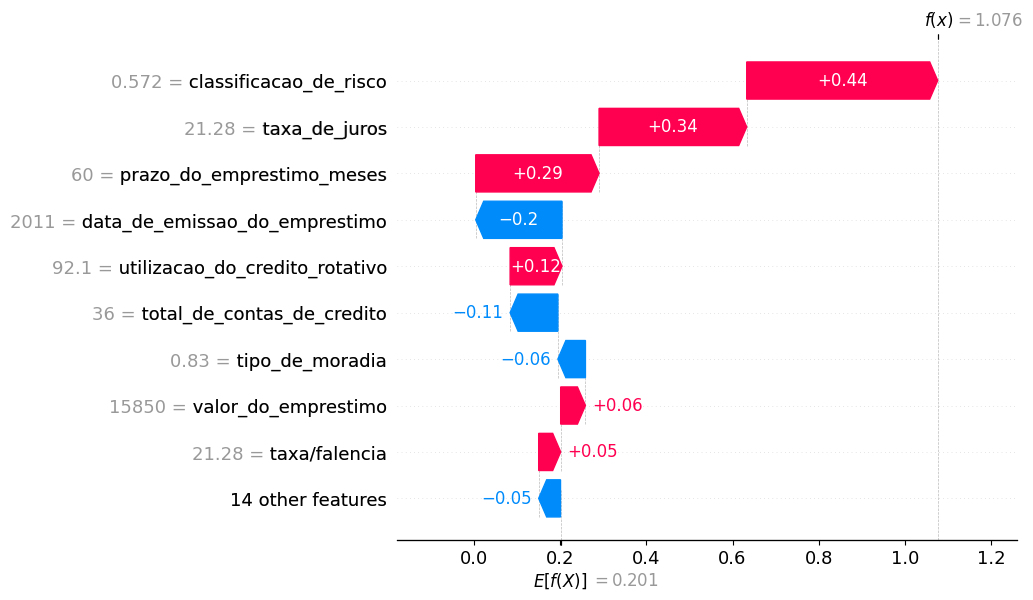

In [ ]:
grafico_waterfall = shap.waterfall_plot(shap_values[0, :],)